# Visualize HPE Results from moveEnet_flowKalman.cpp

This notebook loads predictions from CSV (eval_format) and ground truth from YARP log, computes metrics (PCK, RMSE, MPJPE), and visualizes joint trajectories, skeleton overlays, and PCK curves for dataset cam2_S1_Discussion_ch0.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from pathlib import Path
from datasets.utils import constants as ds_constants, parsing as ds_parsing
from evaluation.utils import metrics as metrics_utils


# Load CSV Data

In [8]:
pred_path = '/home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/raw/np_0p05/cam2_S1_Directions__moveenet_np_0p05.csv'
predictions = np.loadtxt(pred_path, delimiter=',', skiprows=1)
ncols = predictions.shape[1]
ts_pred = predictions[:, 0]

# Detect CSV layout (eval_format vs non-eval)
if ncols in (28, 54):
    # eval_format: ts, latency, 26 coords (x0,y0,...,x12,y12) [+ 26 velocities optional]
    lat_pred = predictions[:, 1]
    joints_pred = predictions[:, 2:28].reshape(-1, 13, 2)
    csv_layout = 'eval_format'
else:
    raise ValueError(f'Unrecognized CSV format with {ncols} columns: {pred_path}')

print(f"Loaded {len(ts_pred)} prediction frames ({csv_layout}, cols={ncols})")

Loaded 6444 prediction frames (eval_format, cols=28)


# Load Log Data

In [9]:
gt_path = Path('/data/moveEnet_test/raw/cam2_S1_Directions/ch0GT200Hzskeleton/data.log')
data = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
print(f"Loaded GT data with {len(data['ts'])} frames")

Loaded GT data with 6445 frames


# Extract Joint Trajectories

In [10]:
ts_gt = np.concatenate(([0.0], data['ts'], [data['ts'][-1] + 1]))
for joint_key in ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys():
    x_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 0]], data[joint_key][:, 0], [data[joint_key][-1, 0]])))
    y_interp = interpolate.interp1d(ts_gt, np.concatenate(([data[joint_key][0, 1]], data[joint_key][:, 1], [data[joint_key][-1, 1]])))
    data[joint_key] = {'x': x_interp, 'y': y_interp}

joints_gt = np.zeros((len(ts_pred), 13, 2))
joint_list = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, ts in enumerate(ts_pred):
    for j, joint in enumerate(joint_list):
        joints_gt[i, j, 0] = data[joint]['x'](ts)
        joints_gt[i, j, 1] = data[joint]['y'](ts)
print("Extracted GT joint trajectories")

Extracted GT joint trajectories


# Compute PCK Metric

In [11]:
if data['head_sizes'][0] != -1:
    pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['head_sizes'][0]], data['head_sizes'], [data['head_sizes'][-1]])))
else:
    pck_sizes_interp = interpolate.interp1d(ts_gt, np.concatenate(([data['torso_sizes'][0]], data['torso_sizes'], [data['torso_sizes'][-1]])))

pck_sizes = pck_sizes_interp(ts_pred)

thresholds = [0.2,0.3, 0.4,0.5, 0.6]
pck_results = {}
for th in thresholds:
    pck_metric = metrics_utils.PCK(th)
    pck_metric.update_samples(joints_pred, joints_gt, pck_sizes)
    pck_results[th] = {'avg': pck_metric.get_value()}

print("PCK Results Summary:")
print("-" * 30)
for th in thresholds:
    overall_pck = pck_results[th]['avg'][1] * 100  # Overall PCK in percentage
    print(f"Threshold {th:.2f}: {overall_pck:.2f}%")
print("-" * 30)

PCK Results Summary:
------------------------------
Threshold 0.20: 97.17%
Threshold 0.30: 99.48%
Threshold 0.40: 99.95%
Threshold 0.50: 100.00%
Threshold 0.60: 100.00%
------------------------------


# Generate PCK Curves


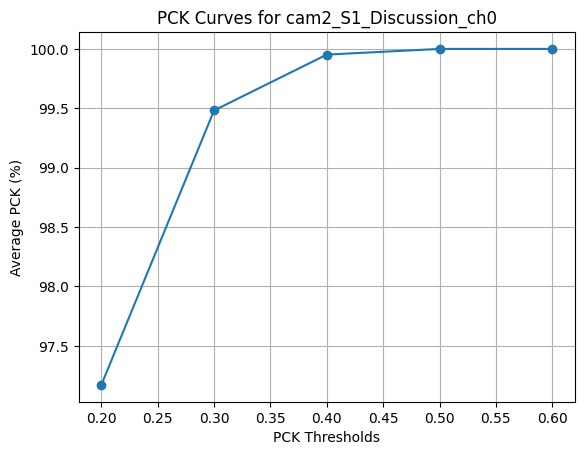

In [12]:
# thresholds = [0.2, 0.4, 0.6]
pck_vals = [pck_results[th]['avg'][1] * 100 for th in thresholds]  # to percentage, take overall avg
plt.figure()
plt.plot(thresholds, pck_vals, marker='o')
plt.xlabel('PCK Thresholds')
plt.ylabel('Average PCK (%)')
plt.title('PCK Curves for cam2_S1_Discussion_ch0')
plt.grid(True)
plt.show()

# Compute RMSE Metric

In [13]:
# True pixel RMSE (no normalization)
# joints_pred, joints_gt shape: (N_frames, 13, 2)
sq_err = (joints_pred - joints_gt) ** 2
mse_per_joint_xy = np.mean(sq_err, axis=0)                  # (13, 2)
rmse_per_joint_xy_px = np.sqrt(mse_per_joint_xy)            # (13, 2)
rmse_per_joint_px = np.sqrt(np.mean(sq_err, axis=(0, 2)))   # (13,)
rmse_global_px = np.sqrt(np.mean(sq_err))                   # scalar

print("RMSE Results Summary (true pixel RMSE):")
print("-" * 40)
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, name in enumerate(joint_names):
    print(f"{name}: {rmse_per_joint_px[i]:.2f} px")
print("-" * 40)
print(f"Total Average (across joints): {rmse_per_joint_px.mean():.2f} px")
print(f"Global RMSE (all joints, all frames): {rmse_global_px:.2f} px")
print("-" * 40)


RMSE Results Summary (true pixel RMSE):
----------------------------------------
head: 3.36 px
shoulder_right: 3.52 px
shoulder_left: 3.27 px
elbow_right: 7.30 px
elbow_left: 4.94 px
hip_left: 3.52 px
hip_right: 2.87 px
wrist_right: 11.40 px
wrist_left: 9.70 px
knee_right: 2.82 px
knee_left: 2.62 px
ankle_right: 5.27 px
ankle_left: 3.81 px
----------------------------------------
Total Average (across joints): 4.95 px
Global RMSE (all joints, all frames): 5.64 px
----------------------------------------


# RMSE Boxplot

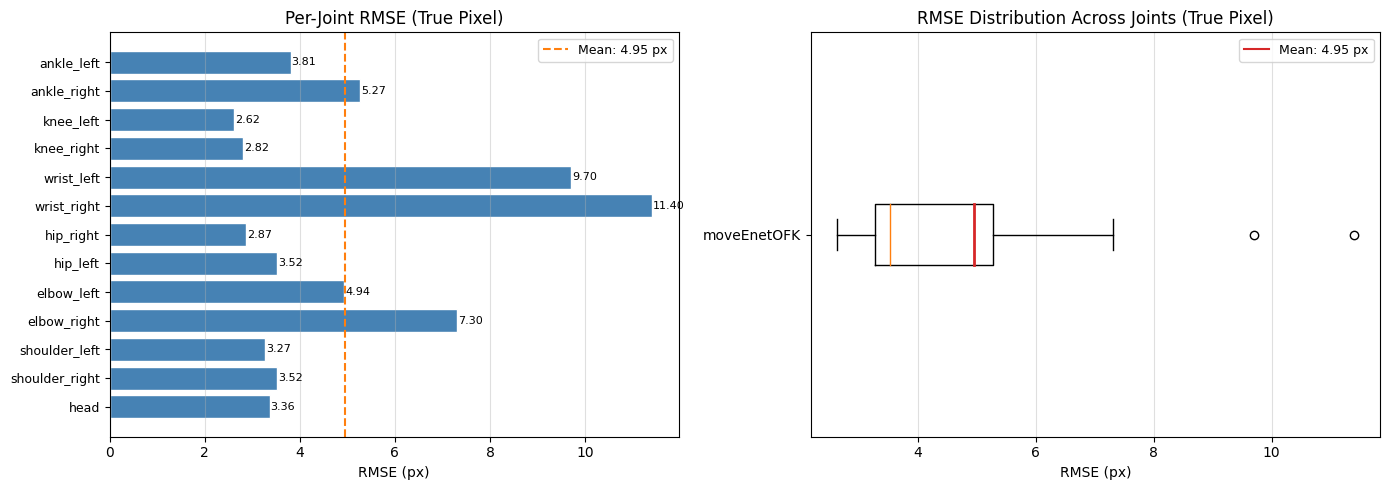

In [14]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
rmse_vals = rmse_per_joint_px  # shape (13,) - per-joint true pixel RMSE

fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-joint horizontal bar chart ---
y_pos = np.arange(len(joint_names))
bars = ax_bar.barh(y_pos, rmse_vals, color='steelblue', edgecolor='white')
ax_bar.axvline(rmse_vals.mean(), color='tab:orange', linestyle='--', linewidth=1.5,
               label=f'Mean: {rmse_vals.mean():.2f} px')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(joint_names, fontsize=9)
ax_bar.set_xlabel('RMSE (px)')
ax_bar.set_title('Per-Joint RMSE (True Pixel)')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, rmse_vals):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)

# --- Right: boxplot showing distribution across joints ---
meanlineprops = dict(linestyle='-', linewidth=2.0, color='tab:red')
ax_box.boxplot([rmse_vals], vert=False, showfliers=True, showmeans=True,
               meanline=True, meanprops=meanlineprops)
ax_box.set_yticks([1])
ax_box.set_yticklabels(['moveEnetOFK'])
ax_box.set_xlabel('RMSE (px)')
ax_box.set_title('RMSE Distribution Across Joints (True Pixel)')
ax_box.grid(axis='x', alpha=0.4)
# Legend for mean line in boxplot
ax_box.plot([], [], color='tab:red', linestyle='-', linewidth=1.5, label=f'Mean: {rmse_vals.mean():.2f} px')
ax_box.legend(fontsize=9)

plt.tight_layout()
plt.show()


# Per-Joint Position Over Time

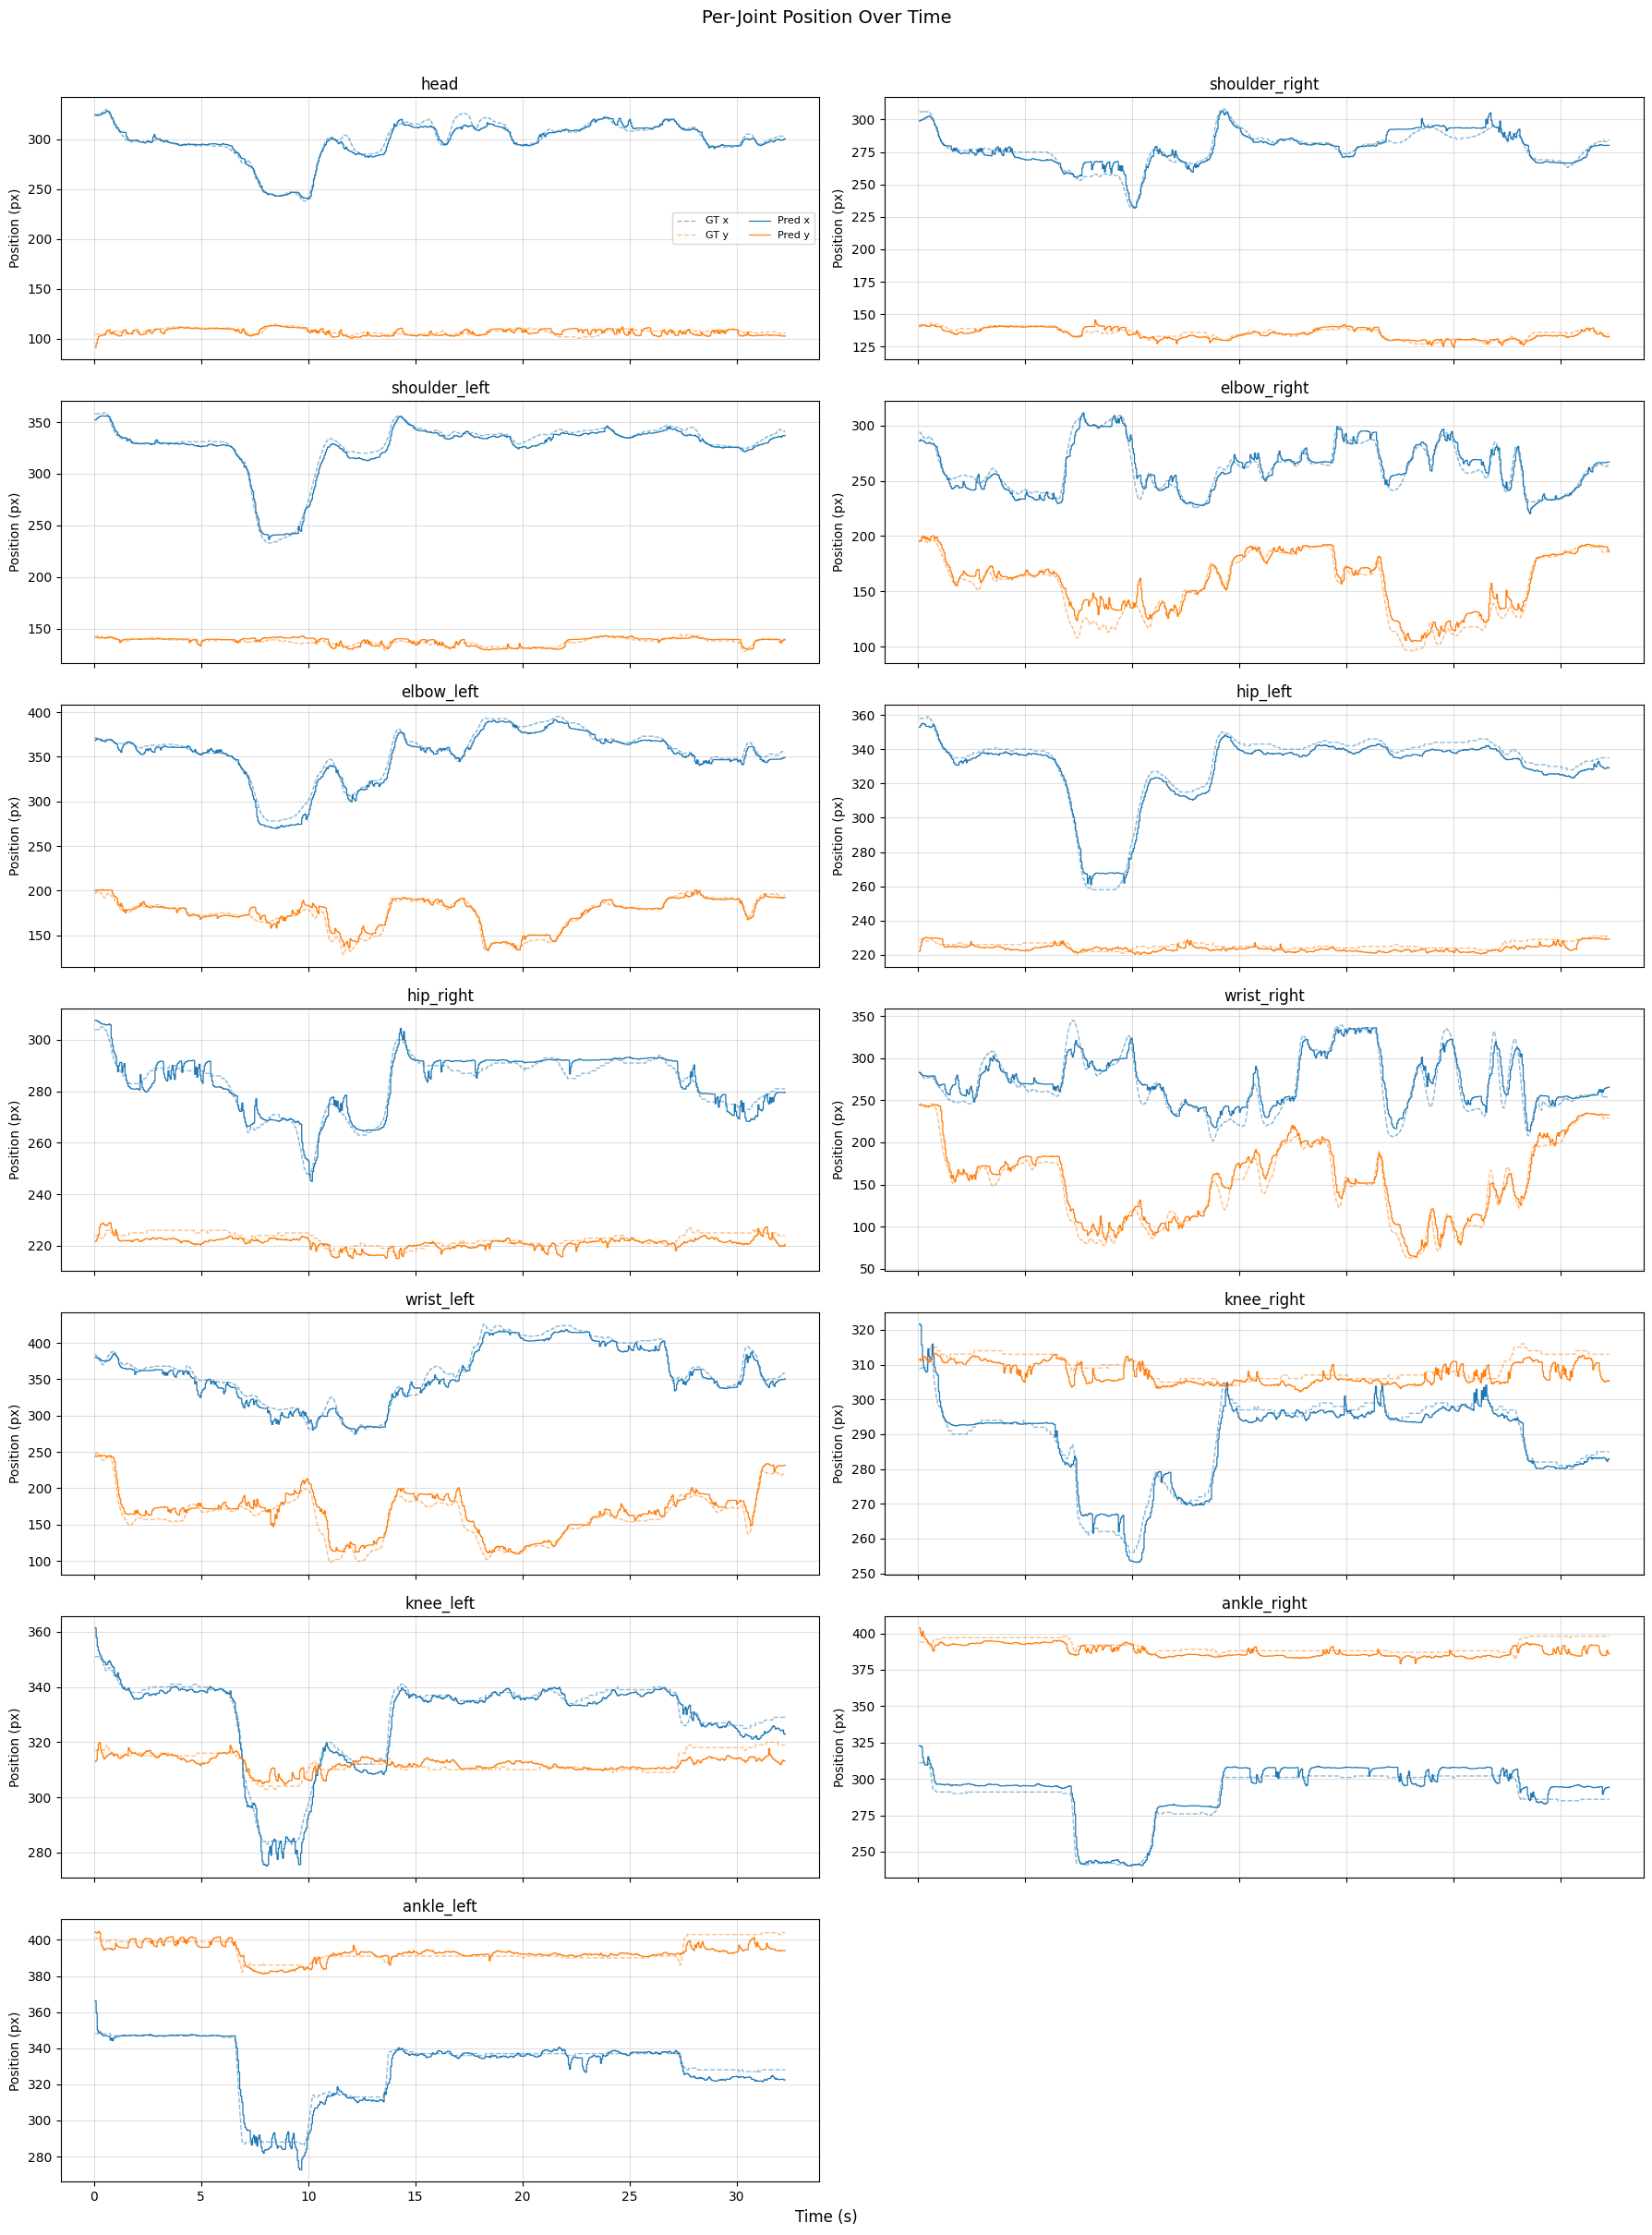

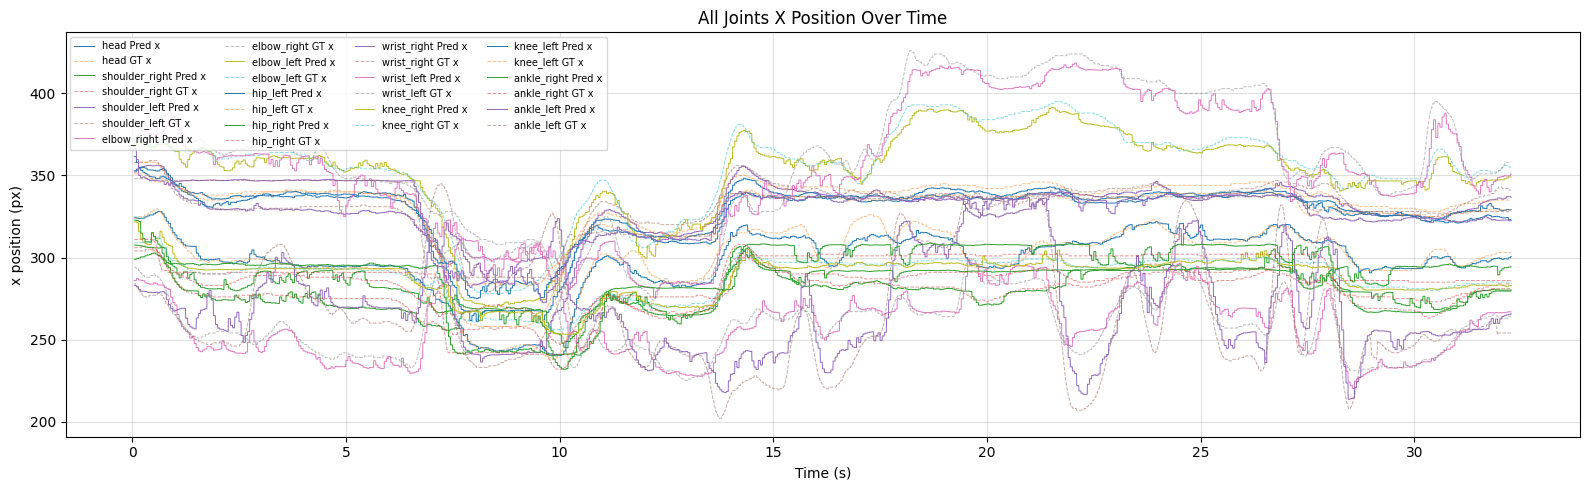

In [20]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

fig, axes = plt.subplots(7, 2, figsize=(18, 24), sharex=True)
axes = axes.flatten()

for j in range(13):
    ax = axes[j]
    ax.plot(ts_pred, joints_gt[:, j, 0], color='tab:blue', alpha=0.5, linewidth=1.0, linestyle='--', label='GT x')
    ax.plot(ts_pred, joints_gt[:, j, 1], color='tab:orange', alpha=0.5, linewidth=1.0, linestyle='--', label='GT y')
    ax.plot(ts_pred, joints_pred[:, j, 0], color='tab:blue', linewidth=0.9, label='Pred x')
    ax.plot(ts_pred, joints_pred[:, j, 1], color='tab:orange', linewidth=0.9, label='Pred y')
    ax.set_title(joint_names[j])
    ax.set_ylabel('Position (px)')
    ax.grid(True, alpha=0.4)
    if j == 0:
        ax.legend(fontsize=8, ncol=2)

axes[13].axis('off')

fig.suptitle('Per-Joint Position Over Time', fontsize=14, y=1.01)
fig.supxlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(16, 5))
for j in range(13):
    ax.plot(ts_pred, joints_pred[:, j, 0], linewidth=0.7, label=f"{joint_names[j]} Pred x")
    ax.plot(ts_pred, joints_gt[:, j, 0], linewidth=0.7, linestyle='--', alpha=0.5, label=f"{joint_names[j]} GT x")

ax.set_xlabel('Time (s)')
ax.set_ylabel('x position (px)')
ax.set_title('All Joints X Position Over Time')
ax.legend(ncol=4, fontsize=7)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# Shoulder Position Over Time

This plot shows the shoulder positions over time on the same axes for both ground truth and prediction.

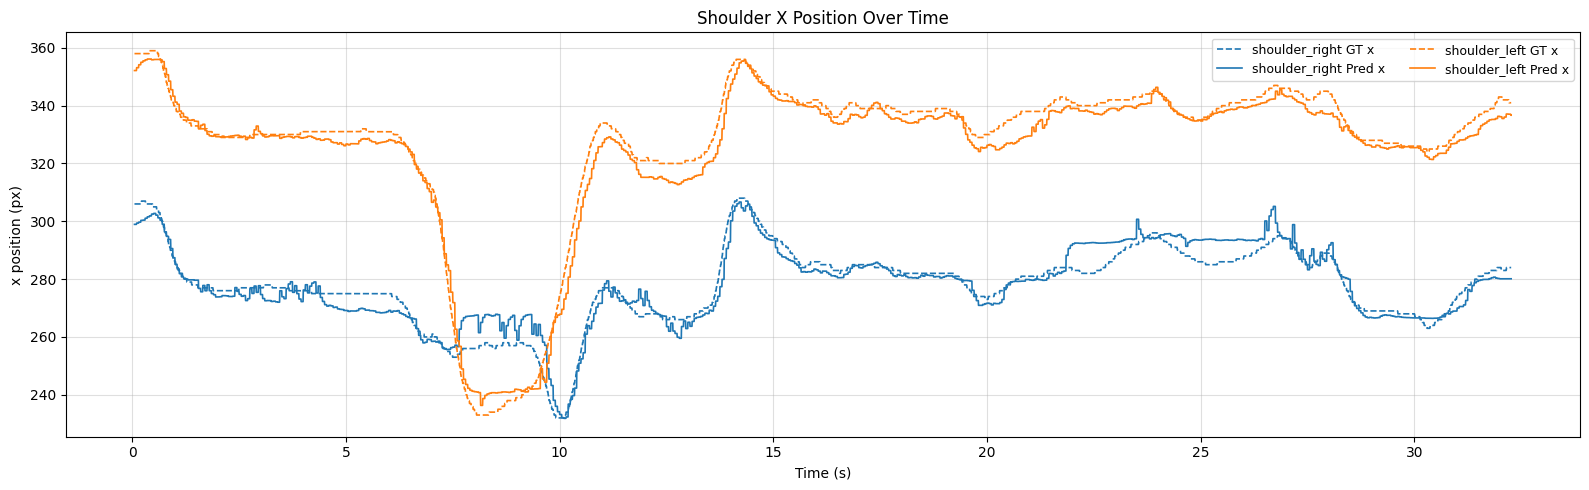

In [19]:
if 'joint_names' not in globals():
    joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

shoulder_indices = [i for i, name in enumerate(joint_names) if 'shoulder' in name.lower()]
if len(shoulder_indices) < 2:
    raise ValueError(f'Expected at least 2 shoulder joints, found: {[joint_names[i] for i in shoulder_indices]}')

fig, ax = plt.subplots(figsize=(16, 5))
colors = ['tab:blue', 'tab:orange']

for color, idx in zip(colors, shoulder_indices[:2]):
    ax.plot(
        ts_pred,
        joints_gt[:, idx, 0],
        color=color,
        linewidth=1.2,
        linestyle='--',
        label=f'{joint_names[idx]} GT x'
    )
    ax.plot(
        ts_pred,
        joints_pred[:, idx, 0],
        color=color,
        linewidth=1.2,
        linestyle='-',
        label=f'{joint_names[idx]} Pred x'
    )

ax.set_xlabel('Time (s)')
ax.set_ylabel('x position (px)')
ax.set_title('Shoulder X Position Over Time')
ax.grid(True, alpha=0.4)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Compute MPJPE Metric

In [ ]:
mpjpe_metric = metrics_utils.MPJPE()
mpjpe_metric.update_samples(joints_pred, joints_gt)
mpjpe_results = mpjpe_metric.get_value()

print("MPJPE Results Summary:")
print("-" * 40)
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
for i, name in enumerate(joint_names):
    mpjpe_val = mpjpe_results[0][i]  # Per-joint MPJPE
    print(f"{name}: {mpjpe_val:.2f} pixels")
print("-" * 40)
print(f"Total Average MPJPE: {mpjpe_results[1]:.2f} pixels")
print("-" * 40)

MPJPE Results Summary:
----------------------------------------
head: 2.89 pixels
shoulder_right: 3.86 pixels
shoulder_left: 3.75 pixels
elbow_right: 5.72 pixels
elbow_left: 5.12 pixels
hip_left: 3.67 pixels
hip_right: 3.48 pixels
wrist_right: 11.95 pixels
wrist_left: 10.14 pixels
knee_right: 3.35 pixels
knee_left: 3.91 pixels
ankle_right: 5.15 pixels
ankle_left: 5.51 pixels
----------------------------------------
Total Average MPJPE: 5.27 pixels
----------------------------------------


# MPJPE Boxplot

In [25]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
mpjpe_per_joint = mpjpe_results[0]  # shape (13,) - per-joint MPJPE

fig, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-joint horizontal bar chart ---
y_pos = np.arange(len(joint_names))
bars = ax_bar.barh(y_pos, mpjpe_per_joint, color='steelblue', edgecolor='white')
ax_bar.axvline(mpjpe_per_joint.mean(), color='tab:orange', linestyle='--', linewidth=1.5,
               label=f'Mean: {mpjpe_per_joint.mean():.2f} px')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(joint_names, fontsize=9)
ax_bar.set_xlabel('MPJPE (px)')
ax_bar.set_title('Per-Joint MPJPE')
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, mpjpe_per_joint):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=8)

# --- Right: boxplot showing distribution across joints ---
meanlineprops = dict(linestyle='-', linewidth=2.0, color='tab:red', label=f'Mean: {mpjpe_per_joint.mean():.2f} px')
ax_box.boxplot([mpjpe_per_joint], vert=False, showfliers=True, showmeans=True,
               meanline=True, meanprops=meanlineprops)
ax_box.set_yticks([1])
ax_box.set_yticklabels(['moveEnetOFK'])
ax_box.set_xlabel('MPJPE (px)')
ax_box.set_title('MPJPE Distribution Across Joints')
ax_box.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()


NameError: name 'mpjpe_results' is not defined

# Visualize Skeleton Overlays

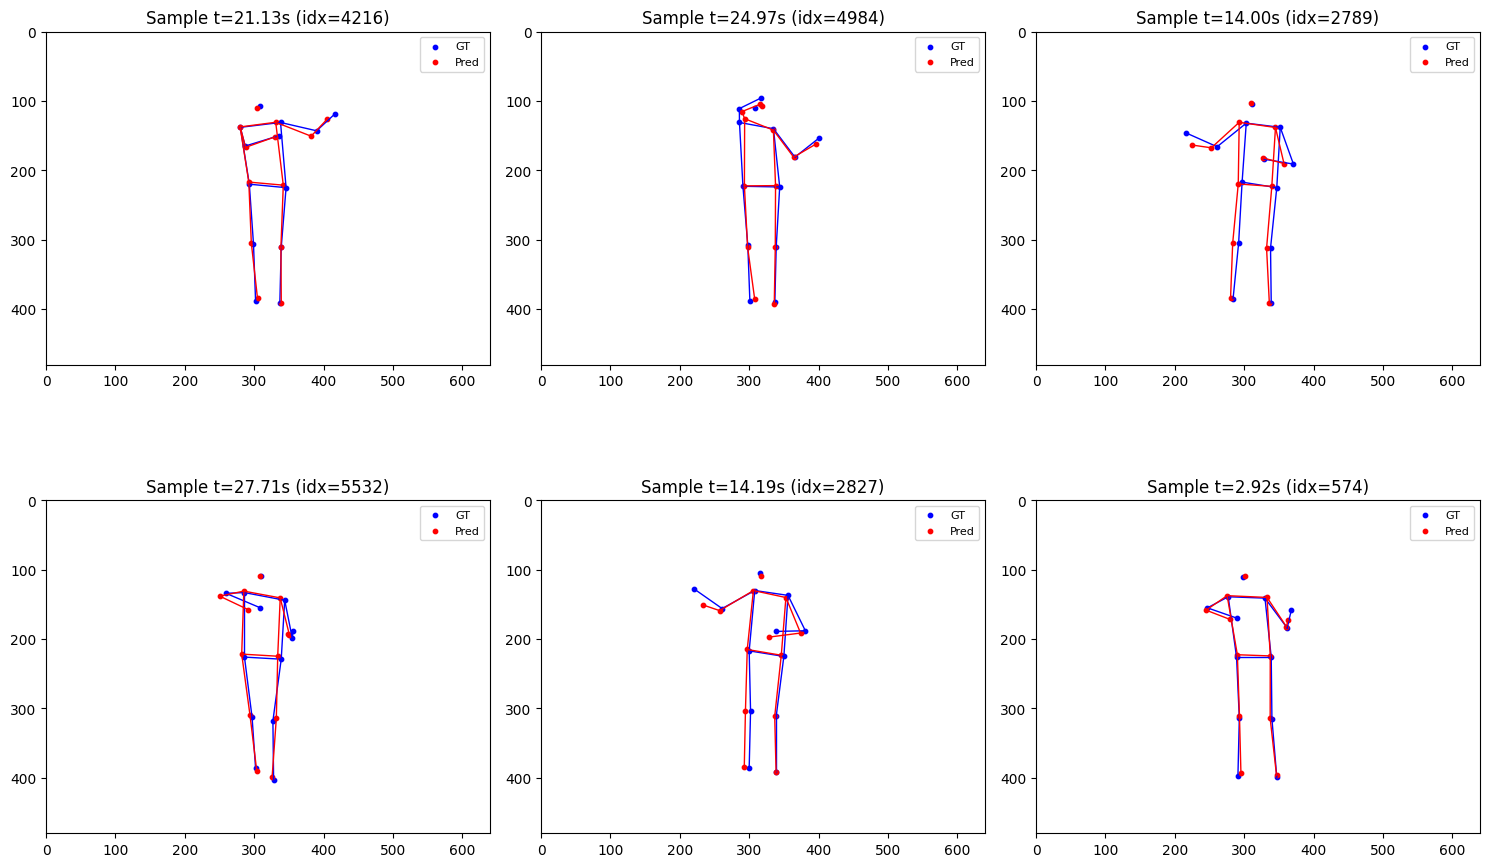

In [23]:
# Define skeleton connections (example, adjust as needed)
skeleton_connections = [
    (1, 2),   # shoulder_right to shoulder_left
    (1, 3),   # shoulder_right to elbow_right
    (1, 6),   # shoulder_right to hip_right
    (2, 4),   # shoulder_left to elbow_left
    (2, 5),   # shoulder_left to hip_left
    (3, 7),   # elbow_right to wrist_right
    (4, 8),   # elbow_left to wrist_left
    (5, 6),   # hip_left to hip_right
    (5, 10),  # hip_left to knee_left
    (6, 9),   # hip_right to knee_right
    (9, 11),  # knee_right to ankle_right
    (10, 12)  # knee_left to ankle_left
 ]

num_samples = 6
total_frames = len(ts_pred)
if total_frames == 0:
    raise ValueError('No prediction frames available to plot')

rng = np.random.default_rng(42)
sample_count = min(num_samples, total_frames)
sample_indices = rng.choice(total_frames, size=sample_count, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax_i, idx in enumerate(sample_indices):
    ax = axes[ax_i]
    # Plot GT
    for j in range(13):
        ax.scatter(joints_gt[idx, j, 0], joints_gt[idx, j, 1], c='blue', s=10, label='GT' if j == 0 else "")
    for conn in skeleton_connections:
        ax.plot([joints_gt[idx, conn[0], 0], joints_gt[idx, conn[1], 0]],
                [joints_gt[idx, conn[0], 1], joints_gt[idx, conn[1], 1]], c='blue', linewidth=1)
    # Plot Pred
    for j in range(13):
        ax.scatter(joints_pred[idx, j, 0], joints_pred[idx, j, 1], c='red', s=10, label='Pred' if j == 0 else "")
    for conn in skeleton_connections:
        ax.plot([joints_pred[idx, conn[0], 0], joints_pred[idx, conn[1], 0]],
                [joints_pred[idx, conn[0], 1], joints_pred[idx, conn[1], 1]], c='red', linewidth=1)

    ax.set_title(f'Sample t={ts_pred[idx]:.2f}s (idx={idx})')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xlim(0, 640)
    ax.set_ylim(480, 0)
    ax.legend(loc='upper right', fontsize=8)

# Hide any unused subplots if < 6 samples
for k in range(sample_count, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()

# Latency Over Time

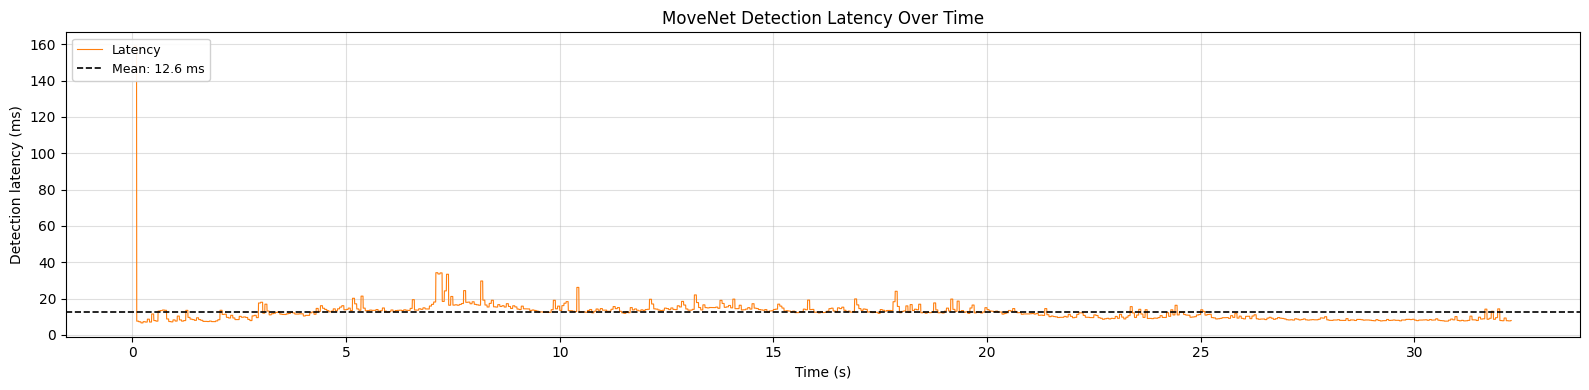

Avg latency: 12.56 ms  |  Min: 6.65 ms  |  Max: 158.97 ms


In [22]:
if csv_layout == 'eval_format':
    fig, ax = plt.subplots(figsize=(16, 4))
    # lat_pred is in seconds (as stored by the C++ code); convert to ms
    ax.plot(ts_pred, lat_pred * 1000, linewidth=0.8, color='tab:orange', label='Latency')
    ax.axhline(np.mean(lat_pred) * 1000, color='black', linestyle='--',
               linewidth=1.2, label=f'Mean: {np.mean(lat_pred)*1000:.1f} ms')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Detection latency (ms)')
    ax.set_title('MoveNet Detection Latency Over Time')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(f"Avg latency: {np.mean(lat_pred)*1000:.2f} ms  |  "
          f"Min: {np.min(lat_pred)*1000:.2f} ms  |  Max: {np.max(lat_pred)*1000:.2f} ms")

else:
    print("Latency data not available (CSV was not recorded in eval_format).")


# Per-Joint x(t) / y(t) Coordinate Trajectories

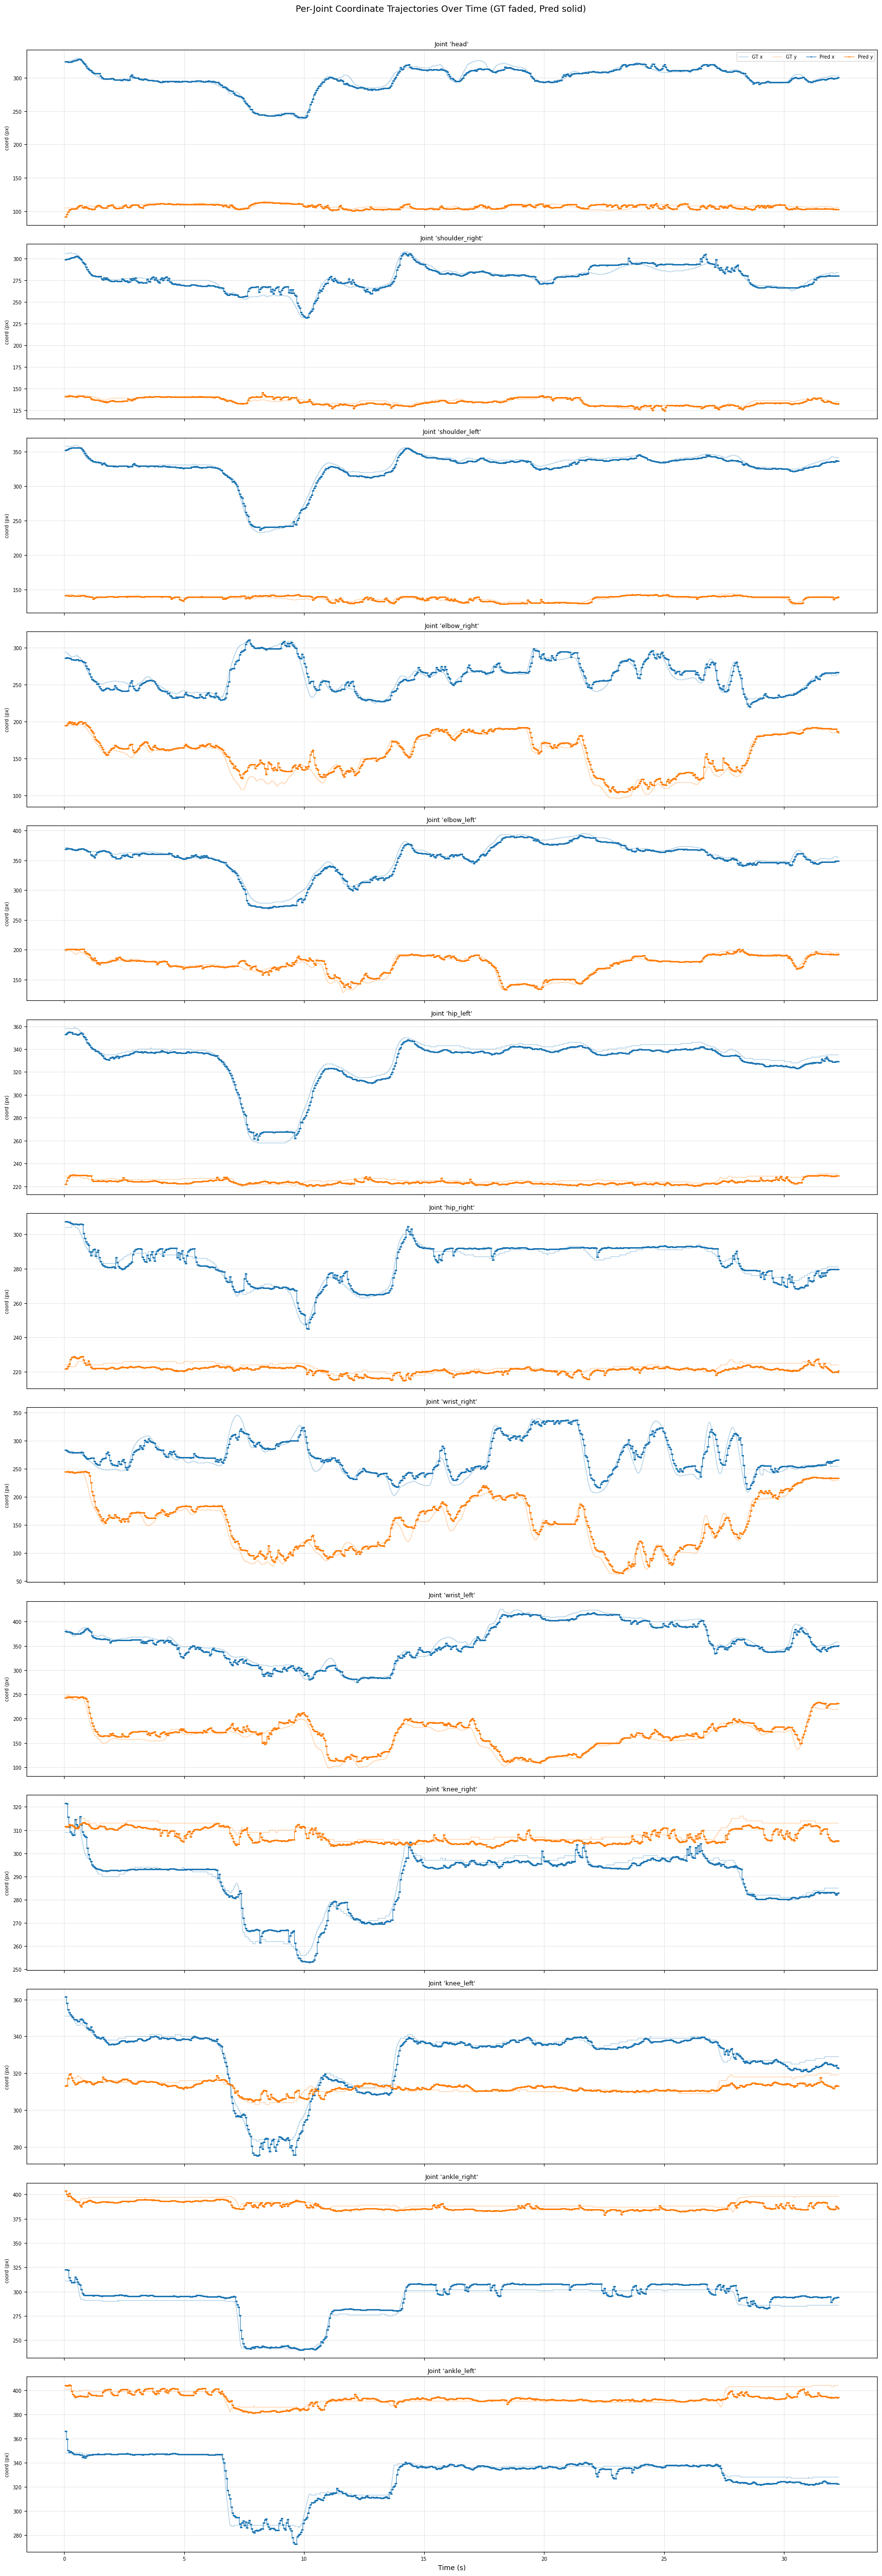

In [21]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())

# One subplot per joint: x(t) and y(t) for GT and prediction
fig, axes = plt.subplots(13, 1, figsize=(18, 52), sharex=True)

for j, (name, ax) in enumerate(zip(joint_names, axes)):
    # GT
    ax.plot(ts_pred, joints_gt[:, j, 0], color='tab:blue',  alpha=0.35, linewidth=1.0, label='GT x')
    ax.plot(ts_pred, joints_gt[:, j, 1], color='tab:orange', alpha=0.35, linewidth=1.0, label='GT y')
    # Prediction
    ax.plot(ts_pred, joints_pred[:, j, 0], color='tab:blue',  alpha=1.0, linewidth=0.8,
            linestyle='-', marker='.', markersize=2, label='Pred x')
    ax.plot(ts_pred, joints_pred[:, j, 1], color='tab:orange', alpha=1.0, linewidth=0.8,
            linestyle='-', marker='.', markersize=2, label='Pred y')
    ax.set_title(f"Joint '{name}'", fontsize=9)
    ax.set_ylabel('coord (px)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.legend(fontsize=7, loc='upper right', ncol=4)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Per-Joint Coordinate Trajectories Over Time (GT faded, Pred solid)', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()
